In [1]:
# simpleCNN
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
from tqdm import tqdm

# ======================
# 路径配置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/simpleCNN/subseasonal_model_cpucc.pth"
OUTPUT_NC = "pred_subseasonal_model_cpucc_20260831.nc"

# ======================
# 输入输出变量
# ======================
input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']

output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 加载数据
# ======================
ds = xr.open_dataset(DATA_PATH)

# ======================
# 数据预处理函数
# ======================
def prepare_input(ds):
    data = []
    time_len = ds.dims["time"]
    for var in input_vars:
        da = ds[var]
        if "time" in da.dims:
            # 转换维度顺序 time, lat, lon
            arr = da.transpose("time", "latitude", "longitude").values
        else:
            # 无time维的，广播到time长度
            arr = np.broadcast_to(da.values, (time_len,) + da.shape)
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)  # (time, channels, lat, lon)
    return np.nan_to_num(data)

X = prepare_input(ds)  # 形状例如 (1, channels, lat, lon)

# ======================
# 模型结构定义
# ======================
class SimpleCNN(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, out_channels, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.model:
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)

# ======================
# 加载模型
# ======================
device = torch.device("cpu")
model = SimpleCNN(len(input_vars), len(output_vars)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ======================
# 推理
# ======================
with torch.no_grad():
    x = torch.from_numpy(X).to(device)  # (1, channels, lat, lon)
    y_pred = model(x).cpu().numpy()     # (1, out_channels, lat, lon)

# 去除batch维度，变为 (channels, lat, lon)
y_pred = y_pred[0]

# ======================
# 保存 NetCDF 文件
# ======================
output_ds = xr.Dataset(
    {var: (("latitude", "longitude"), y_pred[i]) for i, var in enumerate(output_vars)},
    coords={
        "time": ds.time.values,   # 这里的时间是长度为1的时间坐标
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)
# 因为 y_pred 是没有time维度的，所以这里 time 坐标可考虑单独存储或舍弃。
# 如果想保留time维度，可调整y_pred shape并增加time维度。

output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ Saved prediction to {OUTPUT_NC}")


/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/2473849100.py:37: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  time_len = ds.dims["time"]


✅ Saved prediction to pred_subseasonal_model_cpucc_20260831.nc


In [2]:
# SA1
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from tqdm import tqdm
from PIL import Image

# ======================
# 路径配置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/SA1/subseasonal_model_cpu_SA1.pth"
OUTPUT_NC = "pred_subseasonal_model_cpu_SA1_20260831.nc"
#os.makedirs(GIF_DIR, exist_ok=True)

# ======================
# 输入输出变量
# ======================
input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']
output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 加载数据
# ======================
ds = xr.open_dataset(DATA_PATH)

# 填充 NaN
for var in input_vars:
    if ds[var].isnull().any():
        print(f"[NaN Warning] 变量 {var} 中存在 NaN，将填充为 0")
        ds[var] = ds[var].fillna(0)

# ======================
# 数据预处理函数
# ======================
def prepare_input(ds):
    data = []
    time_len = ds.dims["time"]
    for var in input_vars:
        da = ds[var]
        if "time" in da.dims:
            arr = da.transpose("time", "latitude", "longitude").values
        else:
            arr = np.broadcast_to(da.values, (time_len,) + da.shape)
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)
    return np.nan_to_num(data)

X = prepare_input(ds)

# ======================
# 模型结构定义
# ======================
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attn = self.sigmoid(self.conv(x_cat))
        return x * attn

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.attn = SpatialAttention()
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out = self.attn(out)
        out += identity
        return self.relu(out)

class SpatialAttentionResNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock(in_channels, 64),
            ResidualBlock(64, 64),
            ResidualBlock(64, 32),
        )
        self.decoder = nn.Conv2d(32, out_channels, kernel_size=1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# ======================
# 加载模型
# ======================
device = torch.device("cpu")
model = SpatialAttentionResNet(len(input_vars), len(output_vars)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ======================
# 推理
# ======================
Y_pred = []
with torch.no_grad():
    for i in tqdm(range(X.shape[0]), desc="Predicting"):
        x = torch.from_numpy(X[i:i+1]).to(device)
        pred = model(x).cpu().numpy()
        Y_pred.append(pred[0])
Y_pred = np.stack(Y_pred, axis=0)

# ======================
# 保存为 NetCDF
# ======================
output_ds = xr.Dataset(
    {var: (("time", "latitude", "longitude"), Y_pred[:, i]) for i, var in enumerate(output_vars)},
    coords={
        "time": ds.time.values,
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)
output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ Saved prediction to {OUTPUT_NC}")

/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/3441714405.py:46: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  time_len = ds.dims["time"]


[NaN Warning] 变量 elevation 中存在 NaN，将填充为 0


Predicting: 100%|██████████| 1/1 [00:00<00:00, 19.87it/s]

✅ Saved prediction to pred_subseasonal_model_cpu_SA1_20260831.nc


In [3]:
# tc
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
from tqdm import tqdm

# ======================
# 路径配置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/tc/transformer_cnn_model_cpu22.pth"
OUTPUT_NC = "pred_transformer_cnn_model_cpu22_20260831.nc"

# ======================
# 输入输出变量
# ======================
input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']
output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 加载数据
# ======================
ds = xr.open_dataset(DATA_PATH)

# ======================
# 数据预处理函数
# ======================
def prepare_input(ds):
    data = []
    time_len = ds.dims["time"] if "time" in ds.dims else 1
    for var in input_vars:
        da = ds[var]
        if "time" in da.dims:
            arr = da.transpose("time", "latitude", "longitude").values
        else:
            arr = np.expand_dims(da.values, axis=0)  # 加 time 维
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)  # shape: (1, C, H, W)
    return np.nan_to_num(data)

X = prepare_input(ds)

# ======================
# 模型结构定义
# ======================
class TransformerCNN(nn.Module):
    def __init__(self, in_channels, out_channels, height, width, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.patch_embed = nn.Conv2d(in_channels, d_model, kernel_size=3, padding=1)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Sequential(
            nn.Conv2d(d_model, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, out_channels, kernel_size=1)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        x = x.flatten(2).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.permute(0, 2, 1).reshape(B, C, H, W)
        return self.decoder(x)

# ======================
# 加载模型
# ======================
device = torch.device("cpu")
_, C, H, W = X.shape
model = TransformerCNN(len(input_vars), len(output_vars), H, W).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ======================
# 执行推理
# ======================
with torch.no_grad():
    x = torch.from_numpy(X).to(device)
    pred = model(x).cpu().numpy()
Y_pred = pred[0]  # shape: (output_vars, H, W)

# ======================
# 保存 NetCDF 文件
# ======================
output_ds = xr.Dataset(
    {var: (("time", "latitude", "longitude"), np.expand_dims(Y_pred[i], axis=0)) for i, var in enumerate(output_vars)},
    coords={
        "time": ds.time.values,
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)
output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ Saved prediction to {OUTPUT_NC}")


✅ Saved prediction to pred_transformer_cnn_model_cpu22_20260831.nc


/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/1242274729.py:36: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  time_len = ds.dims["time"] if "time" in ds.dims else 1
/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/1242274729.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [4]:
# CG
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
from tqdm import tqdm

# ======================
# 路径配置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/CG/convgru_subseasonal_model1122.pth"
OUTPUT_NC = "pred_convgru_subseasonal_model1122_20260831.nc"

# ======================
# 输入输出变量
# ======================
input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']
output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 加载输入数据
# ======================
ds = xr.open_dataset(DATA_PATH)

# ======================
# 手动定义标准化均值与方差（请根据模型训练时的值填写）
# ======================
mean_std = {}
for var in input_vars:
    mean_std[var] = (ds[var].mean().values, ds[var].std().values or 1.0)

# ======================
# 预处理输入
# ======================
def prepare_input_single(ds):
    data = []
    for var in input_vars:
        arr = ds[var].values
        if arr.ndim == 2:  # (lat, lon)
            arr = arr[None, :, :]  # 添加 time 维度
        mean, std = mean_std[var]
        arr = (arr - mean) / std
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)  # shape: (1, C, lat, lon)
    return np.nan_to_num(data)

X = prepare_input_single(ds)

# ======================
# 模型定义
# ======================
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(input_dim + hidden_dim, 3 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, h_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.conv(combined)
        z, r, h_hat = torch.chunk(gates, 3, dim=1)
        z = torch.sigmoid(z)
        r = torch.sigmoid(r)
        h_hat = torch.tanh(r * h_hat)
        h = (1 - z) * h_prev + z * h_hat
        return h

class ConvGRUNet(nn.Module):
    def __init__(self, input_channels, hidden_channels, output_channels, kernel_size=3):
        super().__init__()
        self.encoder = nn.Conv2d(input_channels, hidden_channels, kernel_size=3, padding=1)
        self.rnn = ConvGRUCell(hidden_channels, hidden_channels, kernel_size=kernel_size)
        self.dropout = nn.Dropout(0.1)
        self.decoder = nn.Conv2d(hidden_channels, output_channels, kernel_size=1)

    def forward(self, x):
        x = self.encoder(x)
        h = torch.zeros_like(x)
        h = self.rnn(x, h)
        h = self.dropout(h)
        out = self.decoder(h)
        return out

# ======================
# 模型推理
# ======================
device = torch.device("cpu")
model = ConvGRUNet(input_channels=len(input_vars), hidden_channels=64, output_channels=len(output_vars))
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

with torch.no_grad():
    x_tensor = torch.from_numpy(X).to(device)  # shape: (1, C, H, W)
    y_pred = model(x_tensor).cpu().numpy()[0]  # shape: (7, H, W)

# ======================
# 保存结果为 NetCDF
# ======================
output_ds = xr.Dataset(
    {var: (("time", "latitude", "longitude"), y_pred[i][None, :, :]) for i, var in enumerate(output_vars)},
    coords={
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
        "time": ds.time.values  # 单时间点
    }
)

output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ 推理结果已保存至: {OUTPUT_NC}")


✅ 推理结果已保存至: pred_convgru_subseasonal_model1122_20260831.nc


In [5]:
# U-net
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from tqdm import tqdm
from PIL import Image
import torch.nn.functional as F

# ======================
# 1. 路径与变量设置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/U-net/subseasonal_model_u.pth"
OUTPUT_NC = "pred_subseasonal_model_u_20260831.nc"
#os.makedirs(os.path.dirname(OUTPUT_NC), exist_ok=True)

input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']
output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 2. 加载数据
# ======================
ds = xr.open_dataset(DATA_PATH)
for var in input_vars:
    if ds[var].isnull().any():
        print(f"[NaN Warning] 变量 {var} 中存在 NaN，将填充为 0")
        ds[var] = ds[var].fillna(0)

def prepare_input(ds):
    time_len = ds.dims["time"] if "time" in ds.dims else 1
    data = []
    for var in input_vars:
        da = ds[var]
        if "time" in da.dims:
            arr = da.transpose("time", "latitude", "longitude").values
        else:
            arr = np.broadcast_to(da.values, (time_len,) + da.shape)
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)
    return np.nan_to_num(data)

X = prepare_input(ds)

# ======================
# UNet带残差块定义（保持不变）
# ======================
def center_crop(tensor, target_size):
    _, _, h, w = tensor.size()
    th, tw = target_size
    x1 = (h - th) // 2
    y1 = (w - tw) // 2
    return tensor[:, :, x1:x1+th, y1:y1+tw]

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)
        if in_c != out_c:
            self.residual = nn.Conv2d(in_c, out_c, 1)
        else:
            self.residual = nn.Identity()
    def forward(self, x):
        res = self.residual(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += res
        return self.relu(out)

class UNet_Res(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.enc1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ResidualBlock(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ResidualBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ResidualBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ResidualBlock(128, 64)

        self.output_layer = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        if u3.size()[2:] != e3.size()[2:]:
            e3 = center_crop(e3, u3.size()[2:])
        d3 = self.dec3(torch.cat([u3, e3], dim=1))

        u2 = self.up2(d3)
        if u2.size()[2:] != e2.size()[2:]:
            e2 = center_crop(e2, u2.size()[2:])
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        if u1.size()[2:] != e1.size()[2:]:
            e1 = center_crop(e1, u1.size()[2:])
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.output_layer(d1)
        if out.shape[2:] != (121, 240):
            out = F.interpolate(out, size=(121, 240), mode='bilinear', align_corners=False)
        return out

# ======================
# 加载模型
# ======================
device = torch.device("cpu")
model = UNet_Res(len(input_vars), len(output_vars)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ======================
# 4. 模型推理
# ======================
Y_pred = []
with torch.no_grad():
    for i in range(X.shape[0]):
        x = torch.from_numpy(X[i:i+1]).to(device)
        pred = model(x).cpu().numpy()
        Y_pred.append(pred[0])
Y_pred = np.stack(Y_pred, axis=0)

# ======================
# 5. 保存 NetCDF 输出
# ======================
output_ds = xr.Dataset(
    {var: (("time", "latitude", "longitude"), Y_pred[:, i]) for i, var in enumerate(output_vars)},
    coords={
        "time": ds.time.values if "time" in ds.coords else [np.datetime64("2025-08-25")],
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)
output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ Saved prediction to {OUTPUT_NC}")


/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/4236294040.py:38: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  time_len = ds.dims["time"] if "time" in ds.dims else 1


[NaN Warning] 变量 elevation 中存在 NaN，将填充为 0
✅ Saved prediction to pred_subseasonal_model_u_20260831.nc


In [6]:
# I
import os
import torch
import torch.nn as nn
import xarray as xr
import numpy as np
from tqdm import tqdm

# ======================
# 路径配置
# ======================
DATA_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/53 20260831/20260831-tas/20260831-tas-1/20260831_weekly_sample_with_pred_and_elev.nc"
MODEL_PATH = "/Users/zhangnan/日常文件/ai/每周下载和预测/推理用/AZN/T2M/I/best_model.pth"
OUTPUT_NC = "pred_best_model_20260831.nc"

# ======================
# 输入输出变量（和你给定一致）
# ======================
input_vars = [f'tas_hist_{i}' for i in range(20)] + \
             [f'gh200_hist_{i}' for i in range(10)] + \
             [f'gh200_300_hist_{i}' for i in range(10)] + \
             [f'gh200_500_hist_{i}' for i in range(10)] + \
             ['pred_t2m_month', 'elevation']

output_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun', 'tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# ======================
# 加载数据（只一个时间点，无需筛选）
# ======================
ds = xr.open_dataset(DATA_PATH)

# ======================
# 输入数据预处理
# ======================
def prepare_input(ds):
    data = []
    # 这里时间长度是1
    time_len = ds.dims["time"]
    for var in input_vars:
        da = ds[var]
        # 输入变量维度一般是 (time, lat, lon) 或 (lat, lon)
        if "time" in da.dims:
            arr = da.transpose("time", "latitude", "longitude").values
        else:
            # elevation在你的数据里是 (time, lat, lon)，但有些变量可能无time维度
            arr = np.broadcast_to(da.values, (time_len,) + da.shape)
        data.append(arr)
    data = np.stack(data, axis=1).astype(np.float32)  # (time, channel, lat, lon)
    return np.nan_to_num(data)

X = prepare_input(ds)

# ======================
# 模型定义（ImprovedNet）
# ======================
class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attn = self.sigmoid(self.conv(x_cat))
        return x * attn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.pool(x).view(b, c)
        y = self.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(b, c, 1, 1)
        return x * y

class ResidualSEBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.se = SEBlock(out_channels)
        self.spatial = SpatialAttention()
        self.skip = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out = self.se(out)
        out = self.spatial(out)
        out += identity
        return self.relu(out)

class ImprovedNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            ResidualSEBlock(in_channels, 64),
            ResidualSEBlock(64, 64),
            ResidualSEBlock(64, 32),
            ResidualSEBlock(32, 32)
        )
        self.decoder = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.layers(x)
        return self.decoder(x)

# ======================
# 加载模型
# ======================
device = torch.device("cpu")
model = ImprovedNet(len(input_vars), len(output_vars)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# ======================
# 推理（只有一个时间点）
# ======================
with torch.no_grad():
    x = torch.from_numpy(X).to(device)  # (1, channel, lat, lon)
    y_pred = model(x).cpu().numpy()     # (1, out_channel, lat, lon)

# ======================
# 保存结果到 NetCDF
# ======================
output_ds = xr.Dataset(
    {var: (("time", "latitude", "longitude"), y_pred[:, i]) for i, var in enumerate(output_vars)},
    coords={
        "time": ds.time.values,
        "latitude": ds.latitude.values,
        "longitude": ds.longitude.values,
    }
)
output_ds.to_netcdf(OUTPUT_NC)
print(f"✅ Saved prediction to {OUTPUT_NC}")

/var/folders/c0/qk4_0hf14hzbrvm5ssh5y5x80000gn/T/ipykernel_78006/3582379514.py:38: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  time_len = ds.dims["time"]


✅ Saved prediction to pred_best_model_20260831.nc


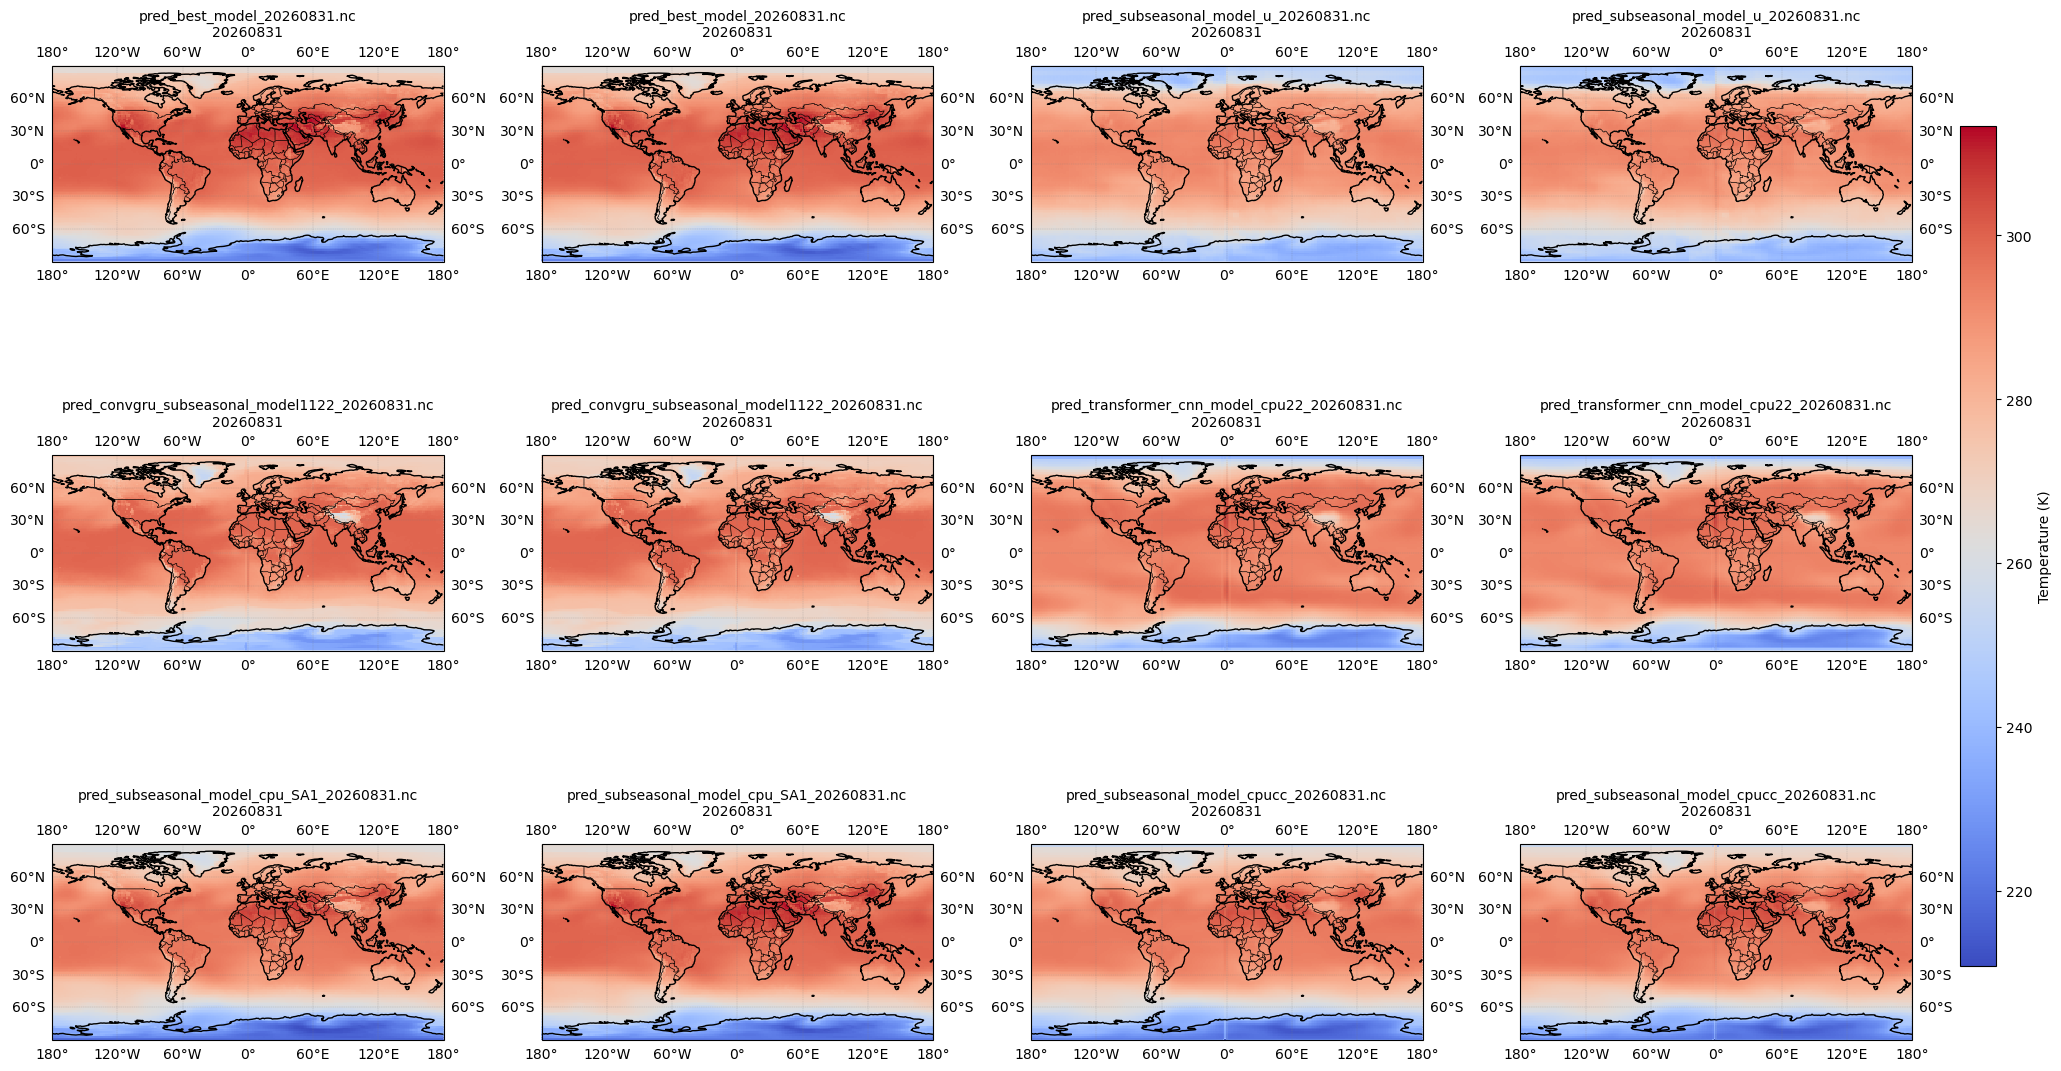

图片已保存至: weekly_temperature_comparison_20260831.png


In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os

# === 文件名列表 ===
file_list = [
    "pred_best_model_20260831.nc",
    "pred_subseasonal_model_u_20260831.nc",
    "pred_convgru_subseasonal_model1122_20260831.nc",
    "pred_transformer_cnn_model_cpu22_20260831.nc",
    "pred_subseasonal_model_cpu_SA1_20260831.nc",
    "pred_subseasonal_model_cpucc_20260831.nc"
]

# 每个文件的两个时间段变量
week1_vars = ['tas_mon', 'tas_wed', 'tas_fri', 'tas_sun']
week2_vars = ['tas_tue_next', 'tas_thu_next', 'tas_sat_next']

# 保存每张图的数据及标题
plots = []

# 预扫描确定统一色标范围
vmin_global = np.inf
vmax_global = -np.inf

for file in file_list:
    ds = xr.open_dataset(file)
    week1_mean = xr.concat([ds[var].squeeze() for var in week1_vars], dim='day').mean(dim='day')
    week2_mean = xr.concat([ds[var].squeeze() for var in week2_vars], dim='day').mean(dim='day')
    plots.append((week1_mean, f"{os.path.basename(file)}\n20260831"))
    plots.append((week2_mean, f"{os.path.basename(file)}\n20260831"))
    vmin_global = min(vmin_global, float(week1_mean.min()), float(week2_mean.min()))
    vmax_global = max(vmax_global, float(week1_mean.max()), float(week2_mean.max()))

# === 创建拼图 ===
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(24, 14), subplot_kw={'projection': ccrs.PlateCarree()})
plt.subplots_adjust(wspace=0.25, hspace=0.3)

cmap = "coolwarm"

# 绘图
for i, (data, title) in enumerate(plots):
    row, col = divmod(i, 4)
    ax = axes[row, col]
    lon = data.longitude.values
    lat = data.latitude.values
    im = ax.pcolormesh(lon, lat, data, cmap=cmap, vmin=vmin_global, vmax=vmax_global, shading='auto')
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=10)
    ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')

# 统一 colorbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Temperature (K)")

# 保存图片
output_file = "weekly_temperature_comparison_20260831.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show(fig)

print(f"图片已保存至: {output_file}")